In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [5]:
# Аугментация для тренировочной выборки против переобучения
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

test_transform = transforms.ToTensor()

In [6]:
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

100%|██████████| 170M/170M [21:46<00:00, 131kB/s]


In [7]:
classes = train_data.classes
print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
len(classes)

10

In [9]:
train = DataLoader(train_data, batch_size=64, shuffle=True)
test = DataLoader(test_data, batch_size=64)

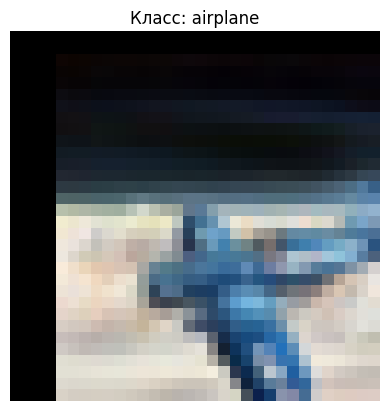

In [10]:
image, label = next(iter(train))
plt.imshow(image[0].permute(1, 2, 0))
plt.title(f'Класс: {classes[label[0]]}')
plt.axis('off')
plt.savefig('image_1')
plt.show()

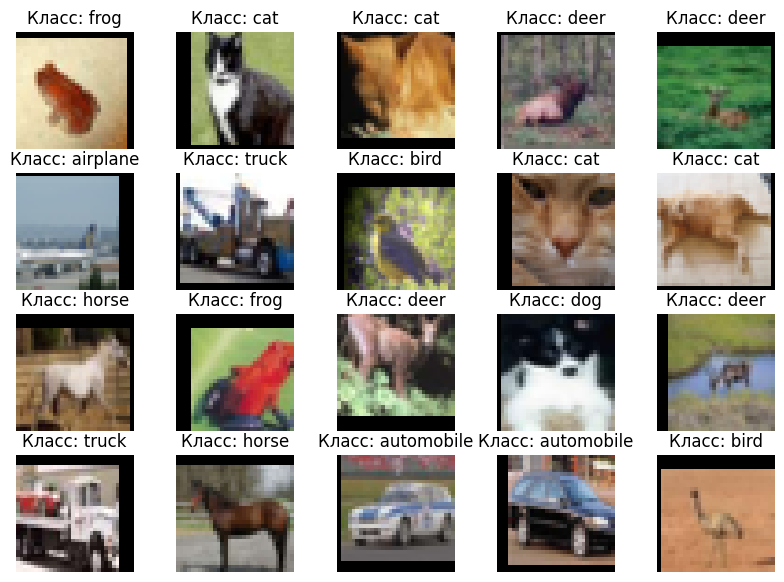

In [11]:
image, label = next(iter(train))
plt.figure(figsize=(10, 10))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(image[i].permute(1, 2, 0))
    plt.title(f'Класс: {classes[label[i]]}')
    plt.axis('off')
plt.subplots_adjust(top=0.65)
plt.savefig('image_set')
plt.show()

In [12]:
# Лучшие параметры для CifarmClassification: lr (learning rate): 0.000357844792847259 / batch_size: 64

In [13]:
class CifarClassification(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.second = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, image):
        image = self.first(image)
        image = self.second(image)
        return image

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

Устройство: cuda


In [15]:
model_CifarClassification = CifarClassification().to(device)

In [16]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_CifarClassification.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [17]:
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

In [18]:
for epoch in range(25):
    model_CifarClassification.train()
    total_loss = 0
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model_CifarClassification(x_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train)
    print(f'Эпоха: {epoch + 1}, Потери: {round(avg_loss, 4)}')

    scheduler.step(avg_loss)

Эпоха: 1, Потери: 1.7506
Эпоха: 2, Потери: 1.4513
Эпоха: 3, Потери: 1.3004
Эпоха: 4, Потери: 1.1941
Эпоха: 5, Потери: 1.1103
Эпоха: 6, Потери: 1.0442
Эпоха: 7, Потери: 0.9916
Эпоха: 8, Потери: 0.9601
Эпоха: 9, Потери: 0.9222
Эпоха: 10, Потери: 0.8927
Эпоха: 11, Потери: 0.8683
Эпоха: 12, Потери: 0.8514
Эпоха: 13, Потери: 0.8341
Эпоха: 14, Потери: 0.8115
Эпоха: 15, Потери: 0.8066
Эпоха: 16, Потери: 0.7897
Эпоха: 17, Потери: 0.7766
Эпоха: 18, Потери: 0.7671
Эпоха: 19, Потери: 0.7524
Эпоха: 20, Потери: 0.744
Эпоха: 21, Потери: 0.7358
Эпоха: 22, Потери: 0.7283
Эпоха: 23, Потери: 0.7199
Эпоха: 24, Потери: 0.7118
Эпоха: 25, Потери: 0.6999


In [19]:
model_CifarClassification.eval()
correct = 0
total = 0
with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model_CifarClassification(x_batch)
        prediction = torch.argmax(y_pred, dim=1)
        total += y_batch.size(0)
        correct += (prediction == y_batch).sum().item()

accuracy = correct * 100 / total
print(f'Точность модели на тестовых данных: {round(accuracy, 2)}%')

Точность модели на тестовых данных: 78.09%


In [20]:
def get_accuracy(data_loader):
    model_CifarClassification.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model_CifarClassification(x_batch)
            prediction = torch.argmax(y_pred, dim=1)
            total += y_batch.size(0)
            correct += (prediction == y_batch).sum().item()
    return round(correct * 100 / total, 2)

print(f'train score: {get_accuracy(train)}%')
print(f'test score: {get_accuracy(test)}%')

train score: 79.11%
test score: 78.09%


In [21]:
torch.save(model_CifarClassification.state_dict(), 'model_CifarClassification_CIFAR_10.pth')

In [23]:
print(train_data.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
